<a href="https://colab.research.google.com/github/danisxde/x5_ml/blob/main/RTO_forecast_march2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏪 Прогноз РТО — март 2025

**Пайплайн:** Препроцессинг → Feature Engineering → Ансамбль (LightGBM + CatBoost + XGBoost) → Предсказание март 2025


## 0. Импорты и настройки

In [34]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)

print("Библиотеки загружены ✓")


Библиотеки загружены ✓


## 1. Загрузка данных

In [35]:
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv('/content/drive/MyDrive/train_2.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Удаление выбросов РТО

Удаляем записи за пределами [1%, 99%] по РТО в обучающей выборке.
Март 2025 (целевой период) из фильтрации исключается.


In [36]:
# Целевой период для предсказания — его не трогаем
TARGET_YEAR, TARGET_MONTH = 2025, 3

feb_2025 = df_raw[(df_raw['Год'] == 2025) & (df_raw['Месяц'] == 2)].copy()
df_target_raw = feb_2025.copy()
df_target_raw['Год'] = 2025
df_target_raw['Месяц'] = 3
df_target_raw['РТО'] = np.nan  # целевая неизвестна

# Обучаем только на данных до марта 2025
df_train_raw = df_raw[~((df_raw['Год'] == 2025) & (df_raw['Месяц'] >= 2))].copy()

print(f"Обучающая выборка до фильтрации: {df_train_raw.shape}")

q_lo = df_train_raw['РТО'].quantile(0.01)
q_hi = df_train_raw['РТО'].quantile(0.99)
df_train_raw = df_train_raw[(df_train_raw['РТО'] >= q_lo) & (df_train_raw['РТО'] <= q_hi)]

print(f"Обучающая выборка после удаления выбросов РТО: {df_train_raw.shape}")
print(f"Целевой период (март 2025): {df_target_raw.shape}")
print(f"\nРТО cutoff: [{q_lo:,.0f} ; {q_hi:,.0f}]")

Обучающая выборка до фильтрации: (466425, 24)
Обучающая выборка после удаления выбросов РТО: (457095, 24)
Целевой период (март 2025): (18657, 24)

РТО cutoff: [30,783,502 ; 264,865,544]


## 3. Feature Engineering

### Что добавляем:
- `log_population`, `log_households` — логарифм численности / домохозяйств
- `log_traffic_auto`, `log_traffic_foot` — логарифм трафика
- `cancels_lag1` — среднее кол-во отмен за **прошлый** месяц (защита от leakage)
- `is_december` — флаг декабря (пик РТО)
- `is_jan_feb` — флаг провала в начале года
- `kassi_per_area` — количество касс как прокси эффективности (нормируем на площадь через OE)
- `month_sin`, `month_cos` — циклическое кодирование месяца
- `target_enc_region` — target encoding региона (fold-wise, без leakage)
- `target_enc_city`   — target encoding населённого пункта


In [37]:
def feature_engineering(df, lag_source=None, is_train=True):
    """
    df         — датафрейм для трансформации
    lag_source — датафрейм-источник для lag-признаков (обычно df_train_raw)
    is_train   — True для обучения, False для инференса
    """
    d = df.copy()

    # ── Логарифмы непрерывных признаков с тяжёлым хвостом ──
    d['log_численность_населения']    = np.log1p(d['Численность населения'])
    d['log_количество_домохозяйств']  = np.log1p(d['Количество домохозяйств'])
    d['log_трафик_авто']              = np.log1p(d['Трафик авто, в час'])
    d['log_трафик_пеший']             = np.log1p(d['Трафик пеший, в час'])

    # ── Clip выбросов по отменам (99-й перцентиль) ──
    if is_train:
        cancels_clip = d['Среднее количество отмен'].quantile(0.99)
    else:
        cancels_clip = (lag_source['Среднее количество отмен'].quantile(0.99)
                        if lag_source is not None else 22500)
    d['cancels_clipped'] = d['Среднее количество отмен'].clip(upper=cancels_clip)

    # ── Lag-признак: отмены за прошлый месяц ──
    src = lag_source if lag_source is not None else d
    lag_map = (src.groupby(['new_id', 'Год', 'Месяц'])['Среднее количество отмен']
                  .mean()
                  .reset_index()
                  .rename(columns={'Среднее количество отмен': 'cancels_lag1'}))
    lag_map['Год_join']  = lag_map['Год']
    lag_map['Месяц_join'] = lag_map['Месяц'] + 1
    lag_map.loc[lag_map['Месяц_join'] > 12, 'Год_join']  += 1
    lag_map.loc[lag_map['Месяц_join'] > 12, 'Месяц_join'] = 1

    d = d.merge(lag_map[['new_id', 'Год_join', 'Месяц_join', 'cancels_lag1']],
                left_on=['new_id', 'Год', 'Месяц'],
                right_on=['new_id', 'Год_join', 'Месяц_join'],
                how='left').drop(columns=['Год_join', 'Месяц_join'])
    # Для строк без лага заполняем медианой магазина
    d['cancels_lag1'] = d['cancels_lag1'].fillna(
        d.groupby('new_id')['cancels_clipped'].transform('median'))

    # ── Сезонные флаги ──
    d['is_december'] = (d['Месяц'] == 12).astype(int)
    d['is_jan_feb']  = (d['Месяц'].isin([1, 2])).astype(int)

    # ── Циклическое кодирование месяца ──
    d['month_sin'] = np.sin(2 * np.pi * d['Месяц'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['Месяц'] / 12)

    # ── Площадь → числовой признак ──
    area_map = {'Маленький': 1, 'Средний': 2, 'Большой': 3, 'Очень большой': 4}
    d['area_ord'] = d['Торговая площадь, категориальный'].map(area_map)

    # ── Возраст магазина → числовой ──
    age_map = {'Новый': 0, 'Средний по возрасту': 1, 'Открыт давно': 2}
    d['age_ord'] = d['Дата открытия, категориальный'].map(age_map)

    # ── Касс на единицу площади (прокси эффективности) ──
    d['kassi_per_area'] = d['Количество касс'] / d['area_ord'].clip(lower=1)

    return d

# Применяем FE к обучающей выборке
df_fe = feature_engineering(df_train_raw, lag_source=df_train_raw, is_train=True)
print(f"После FE: {df_fe.shape[1]} признаков")


После FE: 37 признаков


## 4. Target Encoding (fold-wise, без leakage)

Кодируем `Регион` и `Населённый пункт` средним log(РТО) по фолдам —
так энкодер не видит целевую переменную текущей строки.


In [38]:
def target_encode_fit(df, col, target, n_splits=5, smoothing=20):
    """Fold-wise target encoding. Возвращает (encoded_series, global_mean, group_means)."""
    global_mean = df[target].mean()
    encoded = pd.Series(index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for tr_idx, val_idx in kf.split(df):
        tr = df.iloc[tr_idx]
        group_stats = tr.groupby(col)[target].agg(['mean', 'count'])
        # Сглаживание: blend группового и глобального среднего
        smooth = (group_stats['count'] * group_stats['mean'] + smoothing * global_mean) / (group_stats['count'] + smoothing)
        encoded.iloc[val_idx] = df.iloc[val_idx][col].map(smooth).fillna(global_mean)

    # group_means для инференса
    group_stats_full = df.groupby(col)[target].agg(['mean', 'count'])
    group_means = (group_stats_full['count'] * group_stats_full['mean'] + smoothing * global_mean) / (group_stats_full['count'] + smoothing)
    return encoded, global_mean, group_means

def target_encode_transform(series, group_means, global_mean):
    return series.map(group_means).fillna(global_mean)

# Логарифм РТО — целевая переменная
df_fe['log_rto'] = np.log1p(df_fe['РТО'])

# Кодируем
df_fe['te_region'], te_region_mean, te_region_groups = target_encode_fit(
    df_fe, 'Регион', 'log_rto')
df_fe['te_city'], te_city_mean, te_city_groups = target_encode_fit(
    df_fe, 'Населенный пункт', 'log_rto')

print("Target encoding выполнен ✓")
print(f"  Регион — уникальных значений: {df_fe['Регион'].nunique()}")
print(f"  Населенный пункт — уникальных: {df_fe['Населенный пункт'].nunique()}")


Target encoding выполнен ✓
  Регион — уникальных значений: 67
  Населенный пункт — уникальных: 3268


## 5. Список признаков для модели

In [39]:
FEATURES = [
    # Временные
    'Год', 'Месяц', 'month_sin', 'month_cos',
    'is_december', 'is_jan_feb',

    # Транзакционные (осторожно с отменами — lag версия безопаснее)
    'Среднее количество промо товаров в чеке',
    'Среднее количество товаров в чеке',
    'cancels_clipped',   # оригинал (clipped) — есть на инференсе? уточните
    'cancels_lag1',      # лаговая версия — безопасна всегда
    'Рабочие часы в день',

    # Магазин
    'area_ord', 'age_ord', 'kassi_per_area', 'Количество касс',
    'Флаг алкогольной лицензии',

    # Локация (target-encoded)
    'te_region', 'te_city',

    # Демография и инфраструктура
    'log_численность_населения', 'log_количество_домохозяйств',
    'log_трафик_авто', 'log_трафик_пеший',
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)',
    'Школы (300 м)', 'Остановки (300 м)',
    'Продуктовые магазины (500 м)', 'Пятерочки (500 м)',
]

# Проверяем, что все признаки есть в df
missing = [f for f in FEATURES if f not in df_fe.columns]
if missing:
    print(f"⚠️ Не найдены признаки: {missing}")
    FEATURES = [f for f in FEATURES if f in df_fe.columns]
else:
    print(f"Все {len(FEATURES)} признаков найдены ✓")

TARGET = 'log_rto'
X = df_fe[FEATURES]
y = df_fe[TARGET]
print(f"\nX: {X.shape}, y: {y.shape}")

Все 28 признаков найдены ✓

X: (457095, 28), y: (457095,)


In [40]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457095 entries, 0 to 457094
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Год                                        457095 non-null  int64  
 1   Месяц                                      457095 non-null  int64  
 2   month_sin                                  457095 non-null  float64
 3   month_cos                                  457095 non-null  float64
 4   is_december                                457095 non-null  int64  
 5   is_jan_feb                                 457095 non-null  int64  
 6   Среднее количество промо товаров в чеке    457095 non-null  float64
 7   Среднее количество товаров в чеке          457095 non-null  float64
 8   cancels_clipped                            457095 non-null  float64
 9   cancels_lag1                               457095 non-null  float64
 10  Рабочие 

## 6. Вспомогательные функции оценки

In [41]:
def eval_metrics(y_true_log, y_pred_log, label=''):
    """Метрики в оригинальном масштабе РТО."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label:20s}  MAE={mae/1e6:.2f}M  RMSE={rmse/1e6:.2f}M  MAPE={mape:.2f}%  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2}


## 7. Модель 1 — LightGBM

In [42]:
import re

def clean_col_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_а-яА-ЯёЁ]', '_', col) for col in df.columns]
    return df

X = clean_col_names(X)

# Обновите FEATURES под новые имена
FEATURES = X.columns.tolist()
print(FEATURES)

['Год', 'Месяц', 'month_sin', 'month_cos', 'is_december', 'is_jan_feb', 'Среднее_количество_промо_товаров_в_чеке', 'Среднее_количество_товаров_в_чеке', 'cancels_clipped', 'cancels_lag1', 'Рабочие_часы_в_день', 'area_ord', 'age_ord', 'kassi_per_area', 'Количество_касс', 'Флаг_алкогольной_лицензии', 'te_region', 'te_city', 'log_численность_населения', 'log_количество_домохозяйств', 'log_трафик_авто', 'log_трафик_пеший', 'Маркетплейсы__доставки__постаматы__100_м_', 'Медицинские_уч__и_аптеки__300_м_', 'Школы__300_м_', 'Остановки__300_м_', 'Продуктовые_магазины__500_м_', 'Пятерочки__500_м_']


In [43]:
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

lgb_oof   = np.zeros(len(X))
lgb_models = []

lgb_params = dict(
    objective='regression',
    metric='rmse',
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_estimators=2000,
    random_state=SEED,
    verbose=-1,
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=100),
                         lgb.log_evaluation(500)])
    lgb_oof[val_idx] = model.predict(X_val)
    lgb_models.append(model)
    eval_metrics(y_val.values, lgb_oof[val_idx], f'LGB fold {fold}')

print("\n=== LightGBM OOF ===")
eval_metrics(y.values, lgb_oof, 'LightGBM')

Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 0.142904
[1000]	valid_0's rmse: 0.118761
[1500]	valid_0's rmse: 0.105793
[2000]	valid_0's rmse: 0.0976036
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.0976036
LGB fold 1            MAE=6.15M  RMSE=8.87M  MAPE=7.34%  R²=0.9566
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 0.142231
[1000]	valid_0's rmse: 0.118239
[1500]	valid_0's rmse: 0.105373
[2000]	valid_0's rmse: 0.0970062
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.0970062
LGB fold 2            MAE=6.21M  RMSE=8.87M  MAPE=7.38%  R²=0.9561
Training until validation scores don't improve for 100 rounds
[500]	valid_0's rmse: 0.142561
[1000]	valid_0's rmse: 0.118825
[1500]	valid_0's rmse: 0.105692
[2000]	valid_0's rmse: 0.0973876
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.0973876
LGB fold 3            MAE=6.15M  RMSE=8.87M  MAPE=7.3

{'mae': 6144437.14035486,
 'rmse': np.float64(8835553.010642178),
 'mape': np.float64(7.324575794737753),
 'r2': 0.9565825973624145}

## 8. Модель 2 — XGBoost

In [44]:
xgb_oof    = np.zeros(len(X))
xgb_models = []

xgb_params = dict(
    objective='reg:squarederror',
    eval_metric='rmse',
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_estimators=2000,
    early_stopping_rounds=100,
    random_state=SEED,
    tree_method='hist',
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              verbose=100)
    xgb_oof[val_idx] = model.predict(X_val)
    xgb_models.append(model)
    eval_metrics(y_val.values, xgb_oof[val_idx], f'XGB fold {fold}')

print("\n=== XGBoost OOF ===")
eval_metrics(y.values, xgb_oof, 'XGBoost')


[0]	validation_0-rmse:0.42780
[100]	validation_0-rmse:0.19697
[200]	validation_0-rmse:0.18479
[300]	validation_0-rmse:0.17731
[400]	validation_0-rmse:0.17065
[500]	validation_0-rmse:0.16509
[600]	validation_0-rmse:0.16027
[700]	validation_0-rmse:0.15551
[800]	validation_0-rmse:0.15081
[900]	validation_0-rmse:0.14647
[1000]	validation_0-rmse:0.14247
[1100]	validation_0-rmse:0.13842
[1200]	validation_0-rmse:0.13497
[1300]	validation_0-rmse:0.13166
[1400]	validation_0-rmse:0.12858
[1500]	validation_0-rmse:0.12562
[1600]	validation_0-rmse:0.12299
[1700]	validation_0-rmse:0.12066
[1800]	validation_0-rmse:0.11836
[1900]	validation_0-rmse:0.11612
[1999]	validation_0-rmse:0.11391
XGB fold 1            MAE=7.35M  RMSE=10.43M  MAPE=8.72%  R²=0.9400
[0]	validation_0-rmse:0.42588
[100]	validation_0-rmse:0.19510
[200]	validation_0-rmse:0.18311
[300]	validation_0-rmse:0.17536
[400]	validation_0-rmse:0.16896
[500]	validation_0-rmse:0.16284
[600]	validation_0-rmse:0.15804
[700]	validation_0-rmse:0.153

{'mae': 7219294.721449956,
 'rmse': np.float64(10188652.592967011),
 'mape': np.float64(8.625595388442964),
 'r2': 0.9422662358589602}

## 9. Модель 3 — CatBoost

In [45]:
cat_oof = np.zeros(len(X))
cat_models = []

cat_params = dict(
    iterations=2000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    subsample=0.8,
    colsample_bylevel=0.8,
    eval_metric='RMSE',
    random_seed=SEED,
    verbose=0,
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostRegressor(**cat_params)
    model.fit(X_tr, y_tr,
              eval_set=(X_val, y_val),
              early_stopping_rounds=100,
              verbose=100)
    cat_oof[val_idx] = model.predict(X_val)
    cat_models.append(model)
    eval_metrics(y_val.values, cat_oof[val_idx], f'CAT fold {fold}')

print("\n=== CatBoost OOF ===")
eval_metrics(y.values, cat_oof, 'CatBoost')


0:	learn: 0.4273640	test: 0.4290173	best: 0.4290173 (0)	total: 69.2ms	remaining: 2m 18s
100:	learn: 0.2117467	test: 0.2128773	best: 0.2128773 (100)	total: 6.93s	remaining: 2m 10s
200:	learn: 0.2028538	test: 0.2042995	best: 0.2042995 (200)	total: 12.6s	remaining: 1m 52s
300:	learn: 0.1970288	test: 0.1987676	best: 0.1987676 (300)	total: 19.4s	remaining: 1m 49s
400:	learn: 0.1925939	test: 0.1945761	best: 0.1945761 (400)	total: 25.2s	remaining: 1m 40s
500:	learn: 0.1888495	test: 0.1911306	best: 0.1911306 (500)	total: 31.9s	remaining: 1m 35s
600:	learn: 0.1854913	test: 0.1881116	best: 0.1881116 (600)	total: 37.7s	remaining: 1m 27s
700:	learn: 0.1824436	test: 0.1853477	best: 0.1853477 (700)	total: 44.5s	remaining: 1m 22s
800:	learn: 0.1796181	test: 0.1828433	best: 0.1828433 (800)	total: 50.3s	remaining: 1m 15s
900:	learn: 0.1770206	test: 0.1805688	best: 0.1805688 (900)	total: 57.1s	remaining: 1m 9s
1000:	learn: 0.1744018	test: 0.1782063	best: 0.1782063 (1000)	total: 1m 3s	remaining: 1m 3s
11

{'mae': 10417123.047000585,
 'rmse': np.float64(14385456.26195339),
 'mape': np.float64(12.532611756157982),
 'r2': 0.8849083948262377}

## 10. Ансамбль

Подбираем веса по OOF-предсказаниям, минимизируя RMSE.


In [46]:
from scipy.optimize import minimize

def ensemble_loss(weights, preds_list, y_true):
    w = np.array(weights)
    w = w / w.sum()
    blend = sum(w_i * p for w_i, p in zip(w, preds_list))
    return np.sqrt(mean_squared_error(y_true, blend))

oof_preds = [lgb_oof, xgb_oof, cat_oof]
model_names = ['LightGBM', 'XGBoost', 'CatBoost']

result = minimize(
    ensemble_loss,
    x0=[1/3, 1/3, 1/3],
    args=(oof_preds, y.values),
    method='Nelder-Mead',
    options={'maxiter': 1000}
)
raw_weights = np.array(result.x)
WEIGHTS = raw_weights / raw_weights.sum()

print("Оптимальные веса ансамбля:")
for name, w in zip(model_names, WEIGHTS):
    print(f"  {name}: {w:.3f}")

ensemble_oof = sum(w * p for w, p in zip(WEIGHTS, oof_preds))
print("\n=== Итоговый ансамбль (OOF) ===")
eval_metrics(y.values, ensemble_oof, 'Ensemble')


Оптимальные веса ансамбля:
  LightGBM: 1.262
  XGBoost: 0.236
  CatBoost: -0.498

=== Итоговый ансамбль (OOF) ===
Ensemble              MAE=5.58M  RMSE=8.12M  MAPE=6.58%  R²=0.9633


{'mae': 5578926.29751841,
 'rmse': np.float64(8119505.66205002),
 'mape': np.float64(6.575167780890068),
 'r2': 0.9633346746265911}

## 11. Важность признаков (LightGBM)

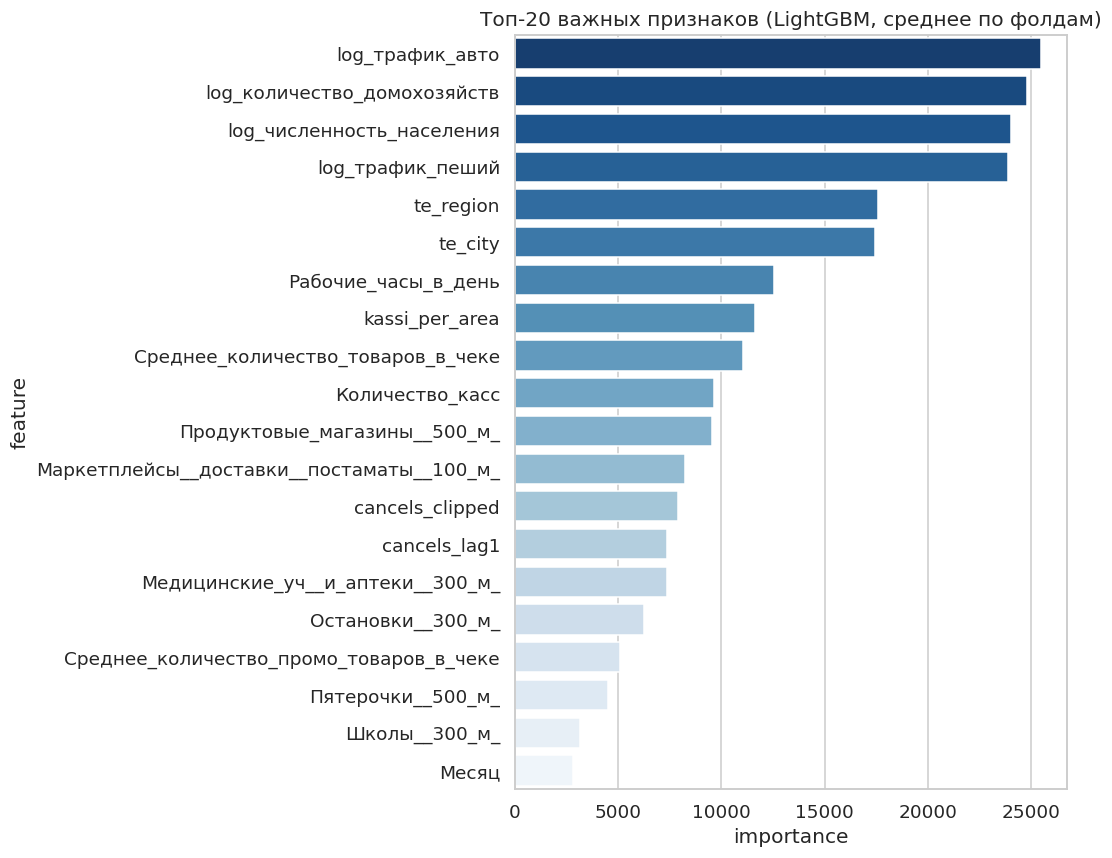

In [47]:
importances = np.mean([m.feature_importances_ for m in lgb_models], axis=0)
imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_df.head(20), x='importance', y='feature', ax=ax, palette='Blues_r')
ax.set_title('Топ-20 важных признаков (LightGBM, среднее по фолдам)')
plt.tight_layout()
plt.show()


## 12. Предсказание РТО — март 2025

Применяем тот же FE-пайплайн к целевому периоду.
Lag-признак (отмены) берётся из февраля 2025.


In [51]:
df_test_fe = feature_engineering(df_target_raw, lag_source=df_train_raw, is_train=False)

df_test_fe['te_region'] = target_encode_transform(
    df_test_fe['Регион'], te_region_groups, te_region_mean)
df_test_fe['te_city'] = target_encode_transform(
    df_test_fe['Населенный пункт'], te_city_groups, te_city_mean)

df_test_fe = clean_col_names(df_test_fe)

# Проверяем наличие признаков
missing_test = [f for f in FEATURES if f not in df_test_fe.columns]
if missing_test:
    print(f"⚠️ Отсутствуют признаки: {missing_test}")
else:
    print("Все признаки на месте ✓")

X_test = df_test_fe[FEATURES]
print(f"Тестовая выборка (март 2025): {X_test.shape}")

Все признаки на месте ✓
Тестовая выборка (март 2025): (18657, 28)


In [54]:
# Предсказания каждой модели (среднее по фолдам)
def predict_ensemble(X_test, models_list, weights, model_type='lgb'):
    fold_preds = []
    for model in models_list:
        fold_preds.append(model.predict(X_test))
    return np.mean(fold_preds, axis=0)

lgb_test = predict_ensemble(X_test, lgb_models, None, 'lgb')
xgb_test = predict_ensemble(X_test, xgb_models, None, 'xgb')
cat_test = predict_ensemble(X_test, cat_models, None, 'cat')

# Взвешенный ансамбль
log_pred = WEIGHTS[0]*lgb_test + WEIGHTS[1]*xgb_test + WEIGHTS[2]*cat_test

# Обратное преобразование
rto_pred = np.expm1(log_pred)

df_result = df_target_raw[['new_id', 'Год', 'Месяц', 'Регион', 'Населенный пункт']].copy()
df_result['РТО_прогноз'] = rto_pred

print(f"Предсказано магазинов: {len(df_result)}")
print(f"\nСреднее прогнозное РТО (март 2025): {rto_pred.mean():,.0f}")
print(f"Медианное прогнозное РТО (март 2025): {np.median(rto_pred):,.0f}")
df_result.head(10)


Предсказано магазинов: 18657

Среднее прогнозное РТО (март 2025): 98,526,608
Медианное прогнозное РТО (март 2025): 86,750,334


,new_id,Год,Месяц,Регион,Населенный пункт,РТО_прогноз
3,0,2025,3,Ярославская обл,Ярославль г,9.349471e+07
31,1,2025,3,Челябинская обл,Магнитогорск г,4.168450e+07
57,2,2025,3,Татарстан Респ,Казань г,8.232975e+07
81,3,2025,3,Самарская обл,Подбельск с,6.372955e+07
108,4,2025,3,Калужская обл,Калуга г,8.754175e+07
134,5,2025,3,Брянская обл,Брянск г,7.678655e+07
161,6,2025,3,Краснодарский край,Краснодар г,1.408694e+08
185,7,2025,3,Кировская обл,Нагорск пгт,7.455353e+07
212,8,2025,3,Московская обл,Малаховка пгт.,2.565860e+08
237,9,2025,3,Ростовская обл,Батайск г,5.726502e+07


## 13. Визуализация прогнозов

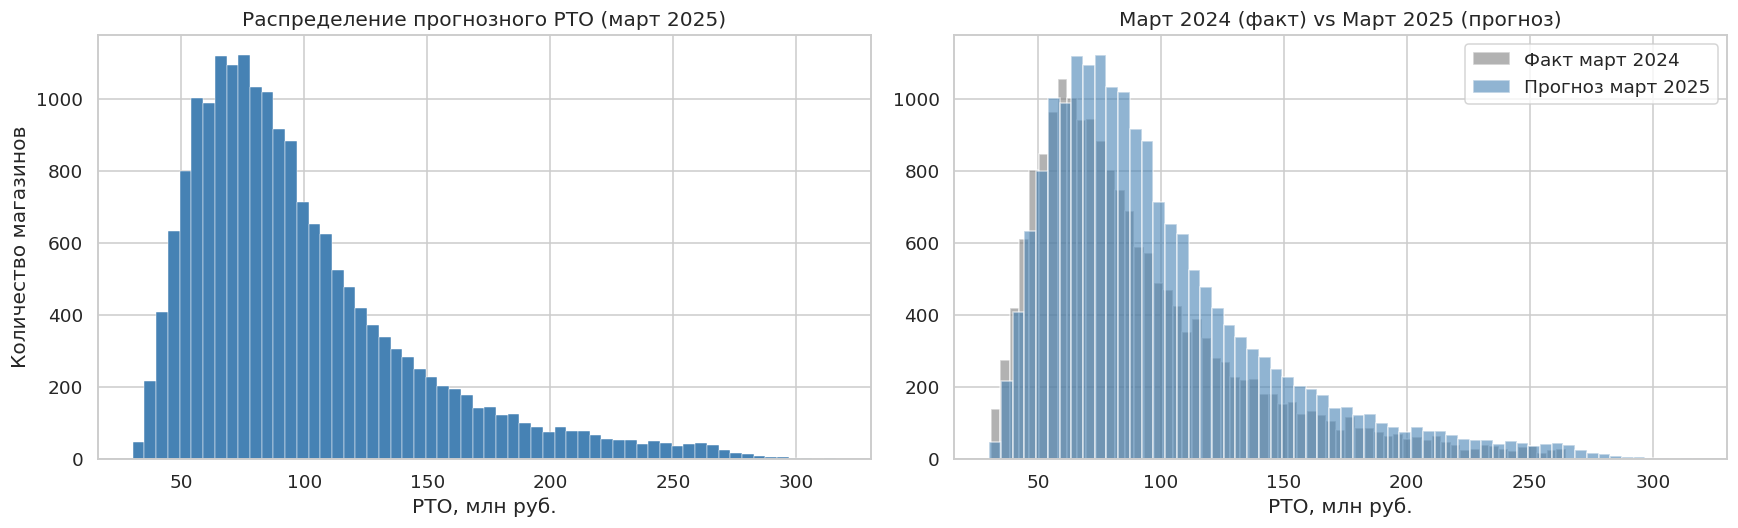


Март 2024 медиана (факт):    78.9 млн
Март 2025 медиана (прогноз): 86.8 млн
YoY рост:                    9.9%


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Распределение прогнозных РТО
axes[0].hist(rto_pred / 1e6, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Распределение прогнозного РТО (март 2025)')
axes[0].set_xlabel('РТО, млн руб.')
axes[0].set_ylabel('Количество магазинов')

# Сравнение: факт март 2024 vs прогноз март 2025
mar_2024 = df_train_raw[(df_train_raw['Год'] == 2024) & (df_train_raw['Месяц'] == 3)]['РТО']
axes[1].hist(mar_2024 / 1e6, bins=60, alpha=0.6, color='gray', edgecolor='white', label='Факт март 2024')
axes[1].hist(rto_pred / 1e6, bins=60, alpha=0.6, color='steelblue', edgecolor='white', label='Прогноз март 2025')
axes[1].set_title('Март 2024 (факт) vs Март 2025 (прогноз)')
axes[1].set_xlabel('РТО, млн руб.')
axes[1].legend()

plt.tight_layout()
plt.show()

# Рост YoY
print(f"\nМарт 2024 медиана (факт):    {mar_2024.median()/1e6:.1f} млн")
print(f"Март 2025 медиана (прогноз): {np.median(rto_pred)/1e6:.1f} млн")
print(f"YoY рост:                    {(np.median(rto_pred)/mar_2024.median()-1)*100:.1f}%")

## 14. Топ-10 и аутсайдеры по прогнозу РТО

In [56]:
print("=== ТОП-10 магазинов по прогнозному РТО (март 2025) ===")
display(df_result.sort_values('РТО_прогноз', ascending=False).head(10)
        .assign(РТО_прогноз_млн=lambda x: (x['РТО_прогноз']/1e6).round(2))
        [['new_id', 'Регион', 'Населенный пункт', 'РТО_прогноз_млн']])

print("\n=== АУТСАЙДЕРЫ — 10 магазинов с наименьшим прогнозом ===")
display(df_result.sort_values('РТО_прогноз').head(10)
        .assign(РТО_прогноз_млн=lambda x: (x['РТО_прогноз']/1e6).round(2))
        [['new_id', 'Регион', 'Населенный пункт', 'РТО_прогноз_млн']])

=== ТОП-10 магазинов по прогнозному РТО (март 2025) ===


,new_id,Регион,Населенный пункт,РТО_прогноз_млн
451987,20241,Москва г,Москва г,316.07
130759,5884,Санкт-Петербург г,Санкт-Петербург г,306.22
114951,5177,Санкт-Петербург г,Санкт-Петербург г,298.17
148411,6673,Москва г,Москва г,296.49
369567,16562,Москва г,Москва г,295.41
60999,2764,Москва г,Москва г,295.22
333013,14921,Санкт-Петербург г,Санкт-Петербург г,292.63
247238,11107,Москва г,Москва г,289.97
408957,18314,Санкт-Петербург г,Санкт-Петербург г,289.83
340032,15225,Москва г,Москва г,289.35



=== АУТСАЙДЕРЫ — 10 магазинов с наименьшим прогнозом ===


,new_id,Регион,Населенный пункт,РТО_прогноз_млн
362444,16245,Саратовская обл,Саратов г,30.28
109439,4931,Башкортостан Респ,Иглино с,30.29
58400,2640,Свердловская обл,Октябрьский п,31.48
354827,15910,Алтайский край,Боровиха с,32.25
359663,16122,Ивановская обл,Кинешма г,32.64
361403,16201,Московская обл,Кашира г,32.68
421437,18873,Волгоградская обл,Камышин г,32.71
11937,538,Пензенская обл,Заречный г,32.76
67447,3052,Свердловская обл,Артемовский г,32.90
393253,17604,Ростовская обл,Морозовск г,32.93


## 15. Сохранение результатов

In [57]:
# Сохраняем прогноз
output_path = 'rto_forecast_march_2025.csv'
df_result.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Прогноз сохранён: {output_path}")
print(df_result.describe())

Прогноз сохранён: rto_forecast_march_2025.csv
             new_id      Год    Месяц   РТО_прогноз
count  18657.000000  18657.0  18657.0  1.865700e+04
mean   10881.244680   2025.0      3.0  9.852661e+07
std     6265.465758      0.0      0.0  4.596441e+07
min        0.000000   2025.0      3.0  3.028036e+07
25%     5455.000000   2025.0      3.0  6.607935e+07
50%    10893.000000   2025.0      3.0  8.675033e+07
75%    16308.000000   2025.0      3.0  1.181242e+08
max    21745.000000   2025.0      3.0  3.160721e+08


In [60]:
submit = pd.DataFrame({
    'new_id': df_result['new_id'],
    'rto': df_result['РТО_прогноз']
    })
submit.to_csv('test.csv', index=False)